In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('data_science_job.csv')

In [4]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [5]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [6]:
df.describe()

,enrollee_id,city_development_index,experience,training_hours,target
count,19158.000000,18679.000000,19093.000000,18392.000000,19158.000000
mean,16875.358179,0.828951,9.928036,65.185787,0.249348
std,9616.292592,0.123334,6.505268,59.885626,0.432647
min,1.000000,0.448000,0.000000,1.000000,0.000000
25%,8554.250000,0.740000,4.000000,23.000000,0.000000
50%,16982.500000,0.903000,9.000000,47.000000,0.000000
75%,25169.750000,0.920000,16.000000,88.000000,0.000000
max,33380.000000,0.949000,20.000000,336.000000,1.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  18679 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  float64
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  training_hours          18392 non-null  float64
 12  target                  19158 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 1.9+ MB


# handling missing data


In [9]:
num_cols = [
    'city_development_index',
    'experience',
    'training_hours'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

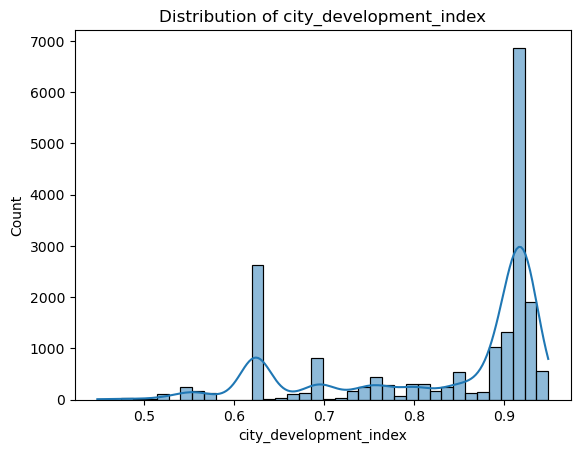

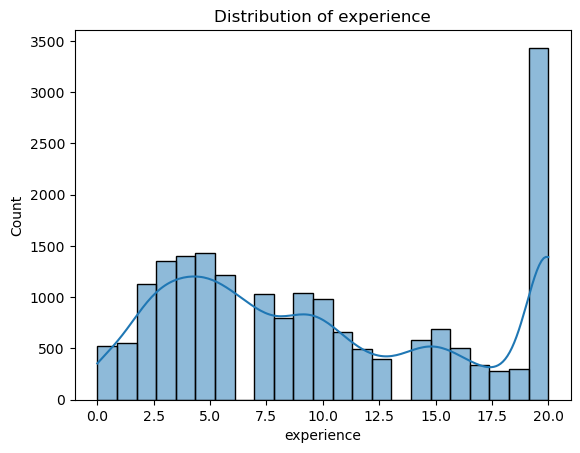

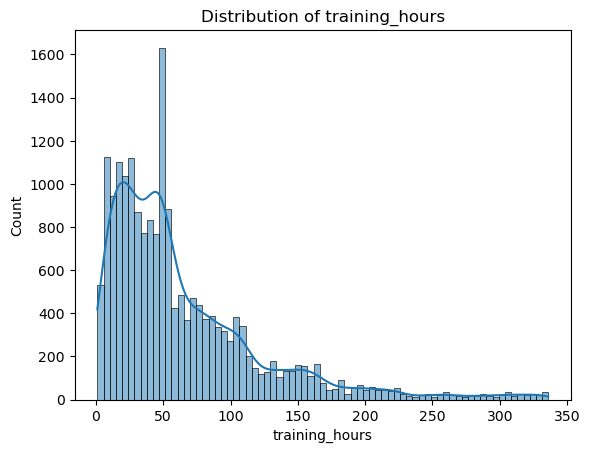

In [10]:
for col in num_cols:
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [11]:
cat_cols = [
    'gender',
    'major_discipline',
    'company_size',
    'company_type'
]

for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

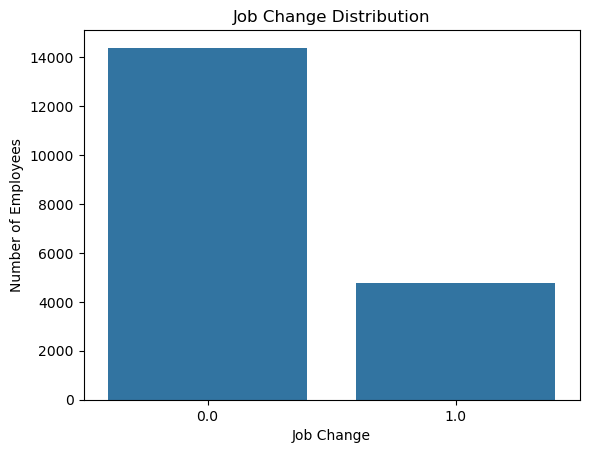

In [12]:
sns.countplot(data=df, x='target')
plt.title('Job Change Distribution')
plt.xlabel('Job Change')
plt.ylabel('Number of Employees')
plt.show()

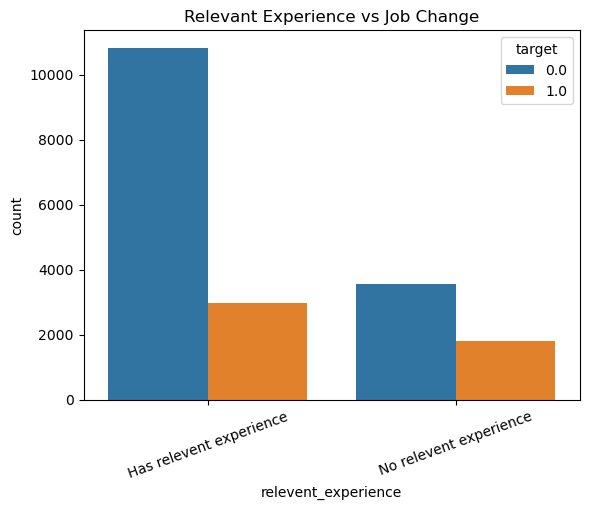

In [13]:
sns.countplot(
    data=df,
    x='relevent_experience',
    hue='target'
)

plt.title('Relevant Experience vs Job Change')
plt.xticks(rotation=20)
plt.show()

In [16]:
numeric_df = df.select_dtypes(include='number')
numeric_df

,enrollee_id,city_development_index,experience,training_hours,target
0,8949,0.920,20.0,36.0,1.0
1,29725,0.776,15.0,47.0,0.0
2,11561,0.624,5.0,83.0,0.0
3,33241,0.789,0.0,52.0,1.0
4,666,0.767,20.0,8.0,0.0
...,...,...,...,...,...
19153,7386,0.878,14.0,42.0,1.0
19154,31398,0.920,14.0,52.0,1.0
19155,24576,0.920,20.0,44.0,0.0
19156,5756,0.802,0.0,97.0,0.0


In [17]:
numeric_df = df.drop('enrollee_id', axis=1).select_dtypes(include='number')

In [18]:
correlation = numeric_df.corr()

print(correlation)

                        city_development_index  experience  training_hours  \
city_development_index                1.000000    0.326908       -0.001250   
experience                            0.326908    1.000000       -0.000352   
training_hours                       -0.001250   -0.000352        1.000000   
target                               -0.334400   -0.177961       -0.021157   

                          target  
city_development_index -0.334400  
experience             -0.177961  
training_hours         -0.021157  
target                  1.000000  


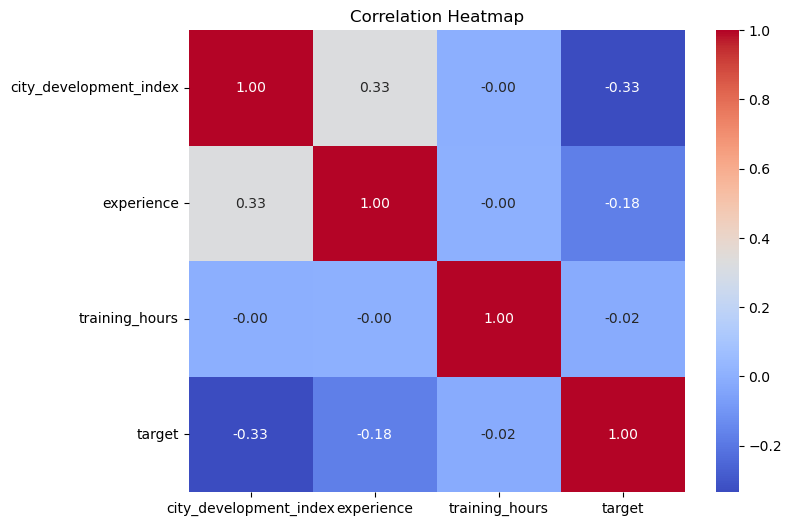

In [19]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

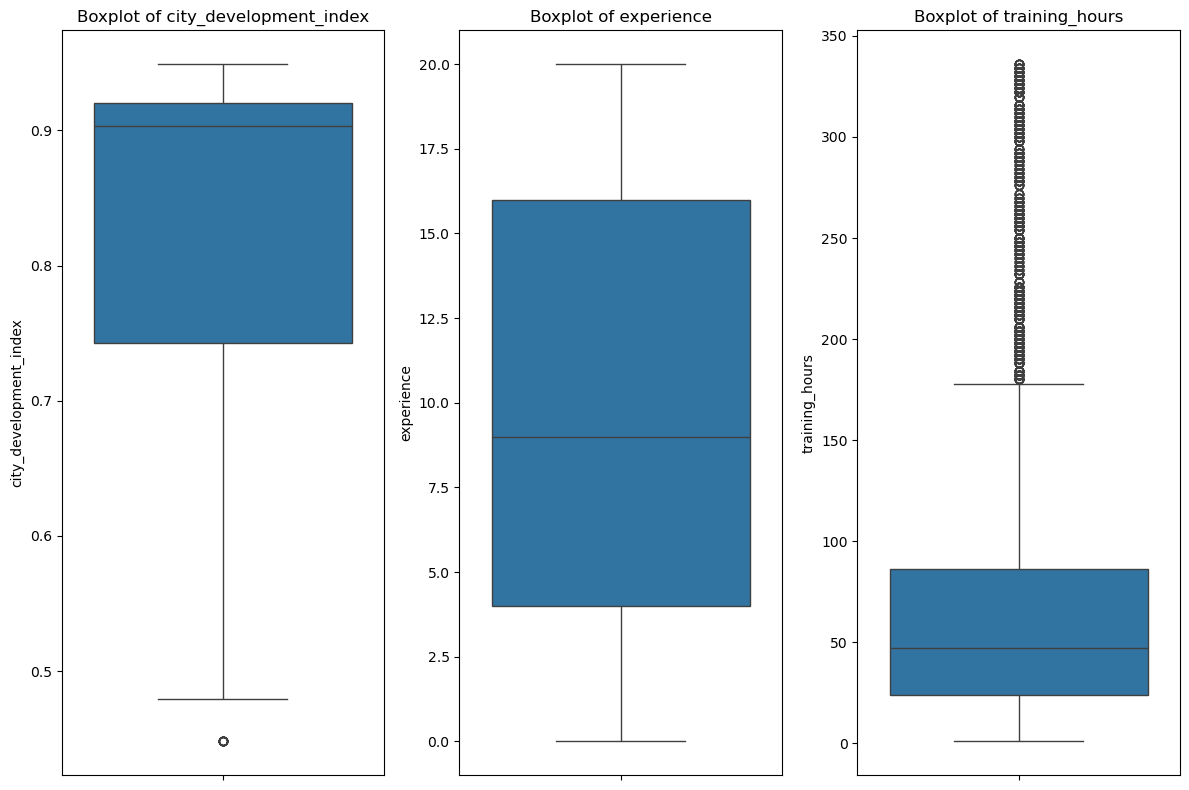

In [20]:
plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()